# EV purchase propensity — EDA and baseline

Mục tiêu: dự đoán **xác suất** `Will_Buy_EV = Yes` cho mỗi dòng của `test.csv`. Notebook này chỉ dùng `train.csv` để học và `test.csv` để suy diễn; `sample_submission.csv` không được đọc hay dùng làm dữ liệu.

In [1]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'playground-series-s6e9'
TRAIN_PATH, TEST_PATH = DATA_DIR / 'train.csv', DATA_DIR / 'test.csv'
OUTPUT_PATH = DATA_DIR / 'submission_baseline.csv'
assert TRAIN_PATH.exists() and TEST_PATH.exists(), f'Missing train/test under {DATA_DIR}'


## 1. Load and validate data

`id` is an identifier and is excluded from features. The checks below make data assumptions explicit before modelling.

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
TARGET, ID_COL = 'Will_Buy_EV', 'id'
FEATURES = [c for c in test.columns if c != ID_COL]

print(f'Train: {train.shape[0]:,} rows × {train.shape[1]} columns')
print(f'Test:  {test.shape[0]:,} rows × {test.shape[1]} columns')
assert set(FEATURES) == set(train.columns) - {ID_COL, TARGET}
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert set(train[TARGET].dropna().unique()) == {'Yes', 'No'}

quality = pd.DataFrame({
    'train_missing': train.isna().sum(),
    'test_missing': test.isna().sum(),
    'train_nunique': train.nunique(),
    'dtype': train.dtypes.astype(str),
})
display(quality)
print('Exact duplicate train rows:', train.duplicated().sum())
display(train.head())


Train: 668,665 rows × 15 columns
Test:  286,571 rows × 14 columns


,train_missing,test_missing,train_nunique,dtype
Age,0,0.0,45,int64
Annual_Income_USD,0,0.0,13214,float64
Charging_Stations_Near_Home,0,0.0,15,int64
Charging_Stations_Near_Work,0,0.0,20,int64
City_Type,0,0.0,3,str
Current_Car_Type,0,0.0,4,str
Daily_Commute_km,0,0.0,805,float64
Environmental_Concern_Level,0,0.0,5,float64
Gender,0,0.0,3,str
Home_Charging_Possible,0,0.0,2,str


Exact duplicate train rows: 0


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## 2. EDA

We inspect class balance and descriptive purchase rates by category. These associations are not causal claims.

Positive rate: 17.46%


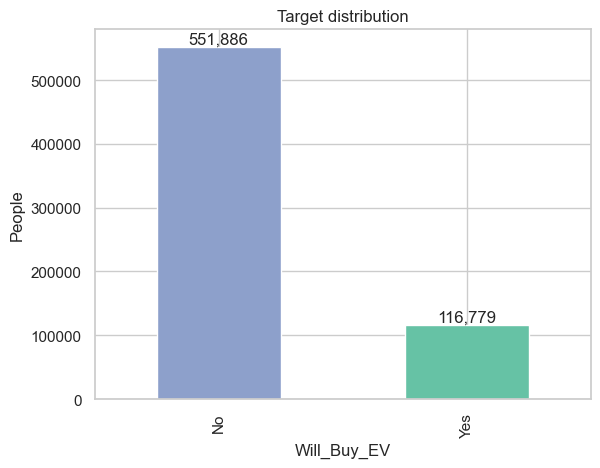

C:\Users\Tony\AppData\Local\Temp\ipykernel_33144\2818969225.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train[FEATURES].select_dtypes(include=['object', 'category']).columns.tolist()


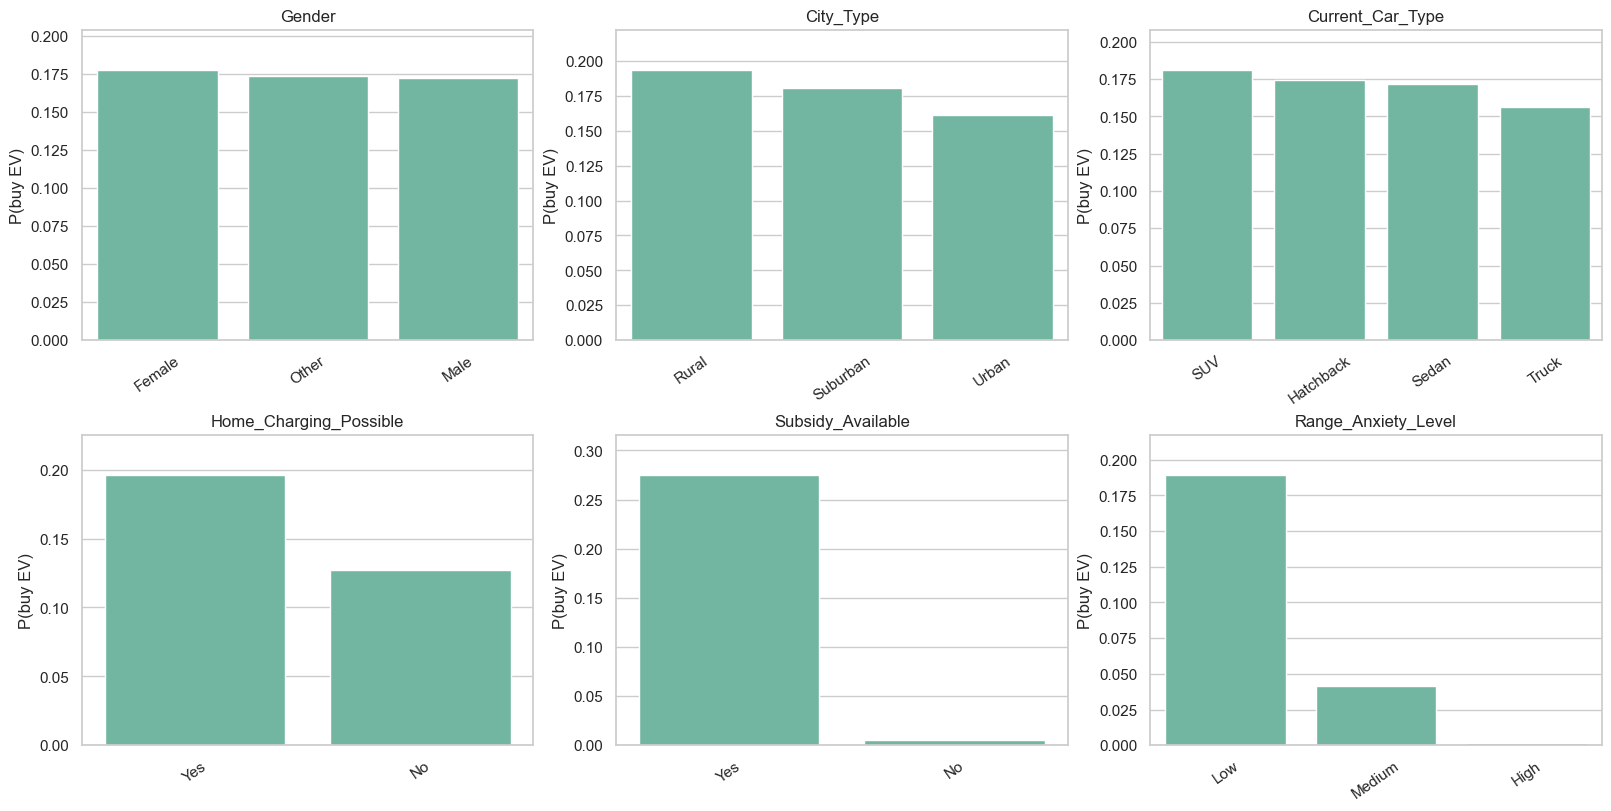

In [3]:
y = train[TARGET].eq('Yes').astype('int8')
print(f'Positive rate: {y.mean():.2%}')
ax = train[TARGET].value_counts().reindex(['No', 'Yes']).plot.bar(color=['#8da0cb', '#66c2a5'])
ax.set(title='Target distribution', xlabel=TARGET, ylabel='People')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
plt.show()

categorical_features = train[FEATURES].select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = [c for c in FEATURES if c not in categorical_features]
ncols, nrows = 3, int(np.ceil(len(categorical_features) / 3))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), constrained_layout=True)
for ax, col in zip(axes.flat, categorical_features):
    rates = train.assign(_y=y).groupby(col, observed=False)['_y'].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, color='#66c2a5', ax=ax)
    ax.set(title=col, xlabel='', ylabel='P(buy EV)', ylim=(0, min(1, rates.max() * 1.15)))
    ax.tick_params(axis='x', rotation=35)
for ax in axes.flat[len(categorical_features):]: ax.remove()
plt.show()


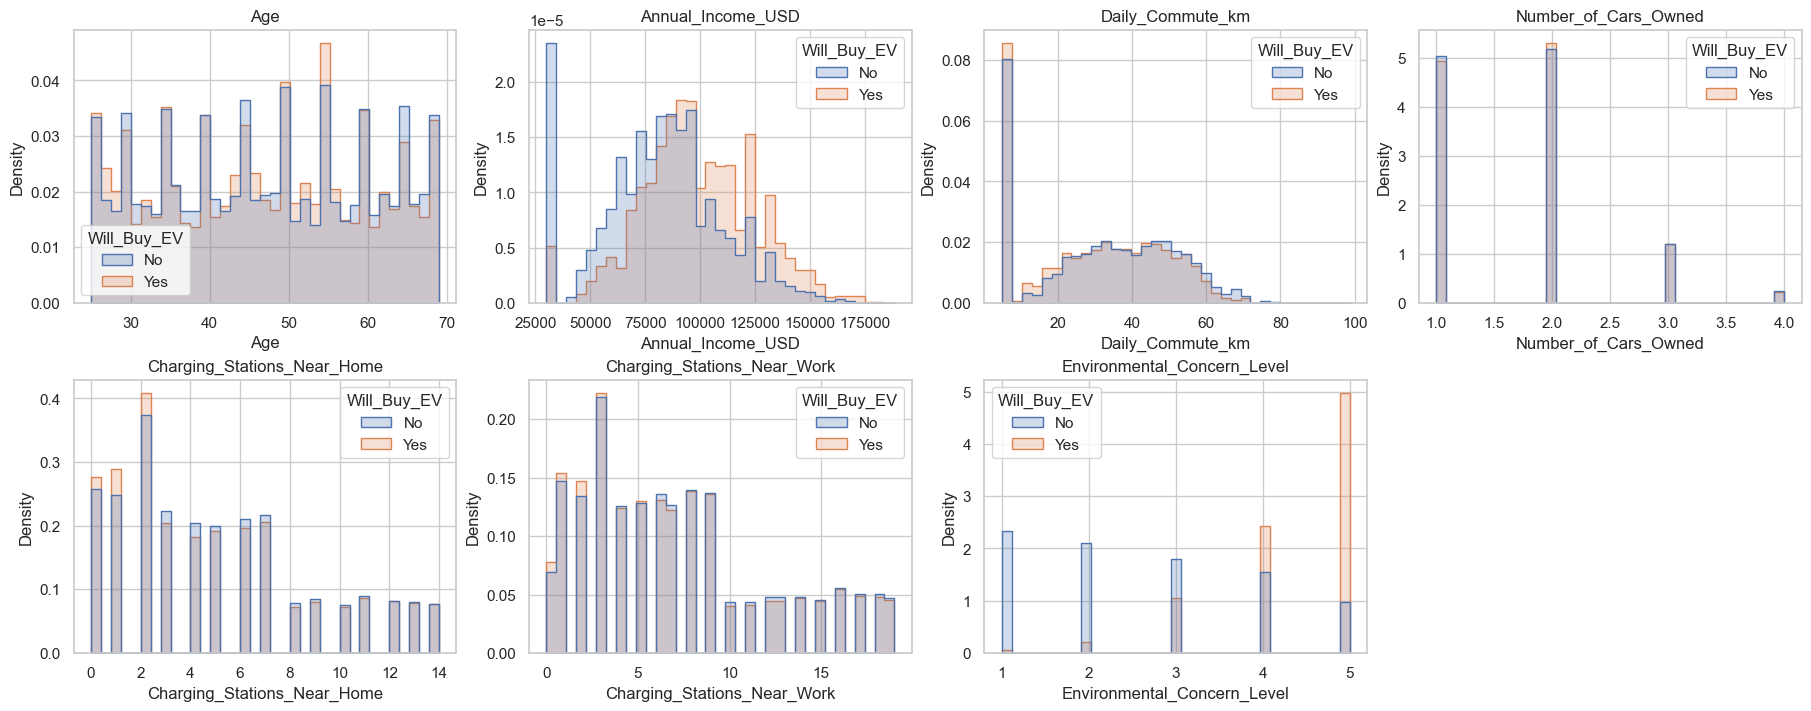

In [4]:
fig, axes = plt.subplots(2, int(np.ceil(len(numeric_features) / 2)), figsize=(18, 7), constrained_layout=True)
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(data=train, x=col, hue=TARGET, stat='density', common_norm=False, bins=35, element='step', ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(numeric_features):]: ax.remove()
plt.show()


## 3. Leakage-safe validation and preprocessing

Validation uses out-of-fold (OOF) predictions from a shuffled 5-fold `StratifiedKFold`. Every learned transform stays inside a `Pipeline`, so a validation fold never affects its fitted imputers, scalers, or encoders. Metrics: ROC-AUC for ranking, and log loss/Brier score for probability quality.

In [8]:
X, X_test = train[FEATURES].copy(), test[FEATURES].copy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

linear_preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
])
tree_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), categorical_features),
])

models = {
    'dummy_prevalence': DummyClassifier(strategy='prior'),
    'logistic_regression': Pipeline([
        ('prep', linear_preprocessor),
        ('model', LogisticRegression(max_iter=300, C=1.0, solver='lbfgs', random_state=RANDOM_STATE)),
    ]),
    'hist_gradient_boosting': Pipeline([
        ('prep', tree_preprocessor),
        ('model', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=32, l2_regularization=1.0, random_state=RANDOM_STATE)),
    ]),
}


,model,roc_auc,average_precision,log_loss,brier_score
0,hist_gradient_boosting,0.94120,0.75374,0.22760,0.07164
1,logistic_regression,0.93796,0.73996,0.23357,0.07375
2,dummy_prevalence,0.50000,0.17465,0.46318,0.14415


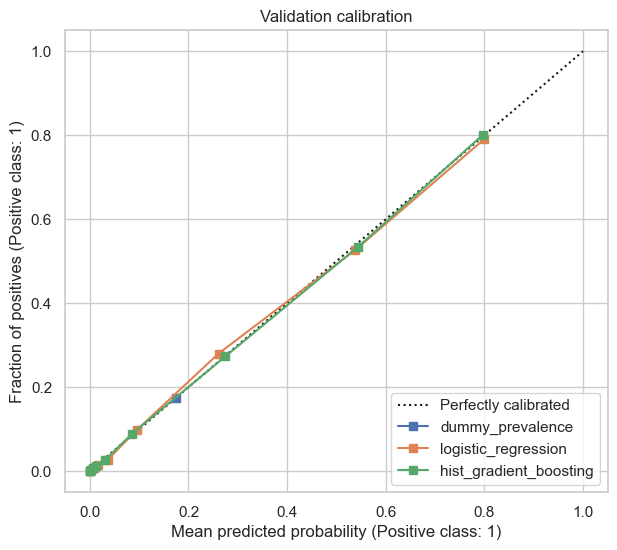

Selected baseline: hist_gradient_boosting


In [9]:
# Tune a compact HGB grid on a reproducible, stratified ~150k-row subset.
# The final model comparison below still uses all rows and 5 OOF folds.
tune_fraction = min(1.0, 150_000 / len(train))
tune_index = train.assign(_target=y).groupby('_target', group_keys=False).sample(frac=tune_fraction, random_state=RANDOM_STATE).index
X_tune, y_tune = X.loc[tune_index], y.loc[tune_index]
tune_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tune_grid = [
    {'max_leaf_nodes': leaves, 'l2_regularization': l2}
    for leaves in (15, 31, 63) for l2 in (0.1, 2.0)
]
tuning_rows = []
for params in tune_grid:
    fold_scores = []
    for fold, (fit_idx, valid_idx) in enumerate(tune_cv.split(X_tune, y_tune), start=1):
        candidate = Pipeline([
            ('prep', clone(tree_preprocessor)),
            ('model', HistGradientBoostingClassifier(learning_rate=0.08, max_iter=180, random_state=RANDOM_STATE, **params)),
        ])
        candidate.fit(X_tune.iloc[fit_idx], y_tune.iloc[fit_idx])
        p = candidate.predict_proba(X_tune.iloc[valid_idx])[:, 1]
        fold_scores.append((roc_auc_score(y_tune.iloc[valid_idx], p), log_loss(y_tune.iloc[valid_idx], p)))
    tuning_rows.append({**params, 'mean_roc_auc': np.mean([s[0] for s in fold_scores]), 'mean_log_loss': np.mean([s[1] for s in fold_scores])})
tuning_results = pd.DataFrame(tuning_rows).sort_values(['mean_roc_auc', 'mean_log_loss'], ascending=[False, True]).reset_index(drop=True)
display(tuning_results.style.format({'mean_roc_auc': '{:.5f}', 'mean_log_loss': '{:.5f}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, metric, title in zip(axes, ['mean_roc_auc', 'mean_log_loss'], ['Tuning: mean ROC-AUC (higher is better)', 'Tuning: mean log loss (lower is better)']):
    matrix = tuning_results.pivot(index='max_leaf_nodes', columns='l2_regularization', values=metric)
    sns.heatmap(matrix, annot=True, fmt='.5f', cmap='viridis_r' if metric == 'mean_log_loss' else 'viridis', ax=ax)
    ax.set_title(title)
plt.show()

best_row = tuning_results.iloc[0]
best_params = {'max_leaf_nodes': int(best_row['max_leaf_nodes']), 'l2_regularization': float(best_row['l2_regularization'])}
models['hist_gradient_boosting_tuned'] = Pipeline([
    ('prep', clone(tree_preprocessor)),
    ('model', HistGradientBoostingClassifier(learning_rate=0.08, max_iter=180, random_state=RANDOM_STATE, **best_params)),
])
print('Selected HGB tuning parameters:', best_params)

# Five-fold OOF evaluation: every person receives a prediction from a model that did not fit that person.
oof_predictions = {name: np.zeros(len(X), dtype=float) for name in models}
fold_rows = []
for fold, (fit_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
    for name, template in models.items():
        fold_model = clone(template)
        fold_model.fit(X.iloc[fit_idx], y.iloc[fit_idx])
        p = fold_model.predict_proba(X.iloc[valid_idx])[:, 1]
        oof_predictions[name][valid_idx] = p
        fold_rows.append({'fold': fold, 'model': name, 'roc_auc': roc_auc_score(y.iloc[valid_idx], p), 'log_loss': log_loss(y.iloc[valid_idx], p)})

rows = []
for name, p in oof_predictions.items():
    rows.append({'model': name, 'roc_auc': roc_auc_score(y, p), 'average_precision': average_precision_score(y, p), 'log_loss': log_loss(y, p), 'brier_score': brier_score_loss(y, p)})
metrics = pd.DataFrame(rows).sort_values(['roc_auc', 'log_loss'], ascending=[False, True]).reset_index(drop=True)
fold_metrics = pd.DataFrame(fold_rows)
display(metrics.style.format({'roc_auc': '{:.5f}', 'average_precision': '{:.5f}', 'log_loss': '{:.5f}', 'brier_score': '{:.5f}'}))
display(fold_metrics.groupby('model')[['roc_auc', 'log_loss']].agg(['mean', 'std']).round(5))

fig, ax = plt.subplots(figsize=(7, 6))
for name, p in oof_predictions.items():
    CalibrationDisplay.from_predictions(y, p, n_bins=10, strategy='quantile', name=name, ax=ax)
ax.set_title('5-fold OOF calibration')
plt.show()
best_name = metrics.loc[0, 'model']
best_oof_probability = oof_predictions[best_name]
print(f'Selected baseline from OOF metrics: {best_name}')


## 4. Calibration by environmental concern and income

These plots use only the selected model's 5-fold OOF probabilities. Therefore, each plotted probability was produced without fitting on that person. `Annual_Income_USD` is divided into equal-frequency quintiles so each group has enough observations.

In [ ]:
income_group = pd.qcut(train['Annual_Income_USD'], q=5, duplicates='drop')
environment_group = train['Environmental_Concern_Level'].astype('string').fillna('Missing')

def calibration_summary(groups, group_name):
    frame = pd.DataFrame({'group': groups.astype(str), 'actual': y, 'predicted': best_oof_probability})
    summary = frame.groupby('group', observed=False).agg(
        people=('actual', 'size'),
        observed_rate=('actual', 'mean'),
        mean_predicted_probability=('predicted', 'mean'),
    )
    summary['calibration_gap'] = summary['mean_predicted_probability'] - summary['observed_rate']
    summary.index.name = group_name
    return summary.reset_index()

environment_summary = calibration_summary(environment_group, 'Environmental_Concern_Level')
income_summary = calibration_summary(income_group, 'Annual_Income_USD quintile')
display(environment_summary.style.format({'observed_rate': '{:.2%}', 'mean_predicted_probability': '{:.2%}', 'calibration_gap': '{:+.2%}'}))
display(income_summary.style.format({'observed_rate': '{:.2%}', 'mean_predicted_probability': '{:.2%}', 'calibration_gap': '{:+.2%}'}))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for group, ax, title in [(environment_group, axes[0], 'Environmental concern level'), (income_group.astype(str), axes[1], 'Annual income quintile')]:
    for label in pd.Series(group).dropna().unique():
        mask = pd.Series(group, index=train.index).astype(str).eq(str(label)).to_numpy()
        CalibrationDisplay.from_predictions(y[mask], best_oof_probability[mask], n_bins=8, strategy='quantile', name=str(label), ax=ax)
    ax.set_title(f'OOF calibration — {title}')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
for summary, group_col, ax, title in [(environment_summary, 'Environmental_Concern_Level', axes[0], 'Environmental concern'), (income_summary, 'Annual_Income_USD quintile', axes[1], 'Annual income')]:
    plot_data = summary.melt(id_vars=[group_col, 'people'], value_vars=['observed_rate', 'mean_predicted_probability'], var_name='series', value_name='rate')
    sns.barplot(data=plot_data, x=group_col, y='rate', hue='series', ax=ax)
    ax.set(title=f'Observed vs mean OOF probability — {title}', xlabel='', ylabel='Rate', ylim=(0, min(1, plot_data['rate'].max() * 1.18)))
    ax.tick_params(axis='x', rotation=30)
plt.show()


## 5. Refit and predict test.csv

Only the selected pipeline is refit on all labelled rows. The saved file is deliberately named `submission_baseline.csv`, so the organizer-provided example remains untouched.

In [10]:
final_model = models[best_name]
final_model.fit(X, y)
test_probability = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({ID_COL: test[ID_COL], TARGET: test_probability})
assert submission.shape == (len(test), 2)
assert submission[ID_COL].equals(test[ID_COL])
assert submission[TARGET].between(0, 1).all() and not submission.isna().any().any()
submission.to_csv(OUTPUT_PATH, index=False)
print(f'Saved new predictions to: {OUTPUT_PATH}')
display(submission.head())
display(submission[TARGET].describe().to_frame('predicted_probability'))


Saved new predictions to: D:\Tony\Career\Personel\Forcasting_Things\data\processed\playground-series-s6e9\submission_baseline.csv


,id,Will_Buy_EV
0,668665,0.008973
1,668666,0.023967
2,668667,0.007720
3,668668,0.003506
4,668669,0.017773


,predicted_probability
count,286571.000000
mean,0.174722
std,0.267792
min,0.000134
25%,0.003274
50%,0.018531
75%,0.275210
max,0.952093


## Next steps

Use stratified cross-validation/out-of-fold predictions for tuning; then check calibration by relevant subgroups (for example charging access, city type, and gender) before operational use.